# Neutral Mutation Rates for Sites of Interest

## Introduction

In our V family DASM analysis, we discovered an intriguing pattern at specific sites located at the edges of CDRs (main sites: 38, 55, 40, 57, 66). These sites exhibit a paradoxical combination of properties:

1. **Wide germline heterogeneity** - Multiple different amino acids are present across V gene families at these positions
2. **Entrenchment** - Despite this heterogeneity, there is a strong preference not to mutate between the different germline amino acids

## Method

To understand the mechanistic basis of this entrenchment, we examine the **neutral mutation rates** at these sites using the Thrifty model. Our hypothesis is that entrenchment might correlate with intrinsic mutational properties of these positions.

We calculate neutral mutation probabilities using:
- The Thrifty neutral mutation model to predict position-specific rates
- A standardized branch length of 0.1 to ensure comparable rates across sites and amino acids
- Calculate specific substitution probabilities: substitution_probability = probability * csp
- We calculate neutral probabilties per nucleotide>nucleotide, translate that to amino acid changes, and then aggregate to create two dataframes:
   - aa_neutral_df - neutral probabilitiy of specific amino acid to specific amino acid
   - aa_to_any_neutral_df - neutral probability of specific amino acid to any

## We find high neutral mutation rate for these sites

**Surprising Result**: Thrifty reveals that these entrenchment sites actually have **high neutral mutation rates** (cell 4). Their high neutral mutation rates are comparable to the CDR areas, but with lower selection factors to mutate away from the germline (cells 9, 12-14). For all of these analyses we focus on mutations away from the germline only.


Hypothesis: looking at the v genes, some sites are more heterogenous then others. Perhaps site-level heterogeneity in V genes might be driven by underlying neutral mutation rates rather than selection, because the gene duplication events that create the germline diversity happen at the DNA level before any functional protein exists. We can test this by comparing neutral mutation patterns (thrifty) to germline diversity (both the level of diversity per site and also specific mutations that occur).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio.Seq import Seq
import seaborn as sns
import os

from torch.nn import functional as F

from netam import pretrained
from netam.models import DEFAULT_NEUTRAL_MODEL

from dnsmex.dxsm_data import pcp_df_of_nickname, anarci_dict
from dnsmex.local import localify
from dnsmex.dasm_oe import write_sites_oe
from netam.oe_plot import annotate_sites_df, annotate_site_csp_df, get_numbering_dict
from utils import add_germline_information

figures_dir = localify("FIGURES_DIR")

In [2]:
dataset = "v1rodriguez"
#dataset = 'v1rodriguez_short'
neutral_model_name = DEFAULT_NEUTRAL_MODEL


class MutabilityContainer:
    def __init__(self, neutral_model_name, dataset):
        pcp_df = pcp_df_of_nickname(dataset, add_shm_outputs=True)
        self.pcp_df = pcp_df
        crepe = pretrained.load(neutral_model_name)
        
        self.rates, self.csp_logits = crepe(self.pcp_df["parent_heavy"])

        self.csp_rates = F.softmax(self.csp_logits, dim=2)


        anarci_path = anarci_dict[dataset]
        print(f"Using ANARCI path: {anarci_path}")
        if "imgt" in anarci_path:
            self.numbering_type = "IMGT"
        
        pcp_df_heavy = pcp_df

        for colname in pcp_df.columns:
            shortened_colname = colname[: -len("_heavy")]
            if colname.endswith("_heavy"):
                pcp_df_heavy[shortened_colname] = pcp_df_heavy[colname]

        self.pcp_df = pcp_df_heavy

        self.numbering, _ = get_numbering_dict(
            anarci_path['heavy'], self.pcp_df, verbose=True, checks="imgt"
        )

        self.create_nucleotide_neutral_rates_df()
        self.create_amino_acids_neutral_rates_df()
        self.create_amino_acid_to_any_neutral_rates_df()
    
    def create_nucleotide_neutral_rates_df(self):
        """
        Create a dataframe with one row per sequence, site, and nucleotide.
        No aggregations - just raw rates and csp_logits.
        Includes codon information and transition details.
        
        Returns:
        - DataFrame with columns: sequence_idx, site, nucleotide, rate, csp_logit,
                                 current_codon, codon_position, current_nucleotide, 
                                 transition_from, transition_to
        """
        n_sequences = self.rates.shape[0]
        n_sites = self.rates.shape[1] 
        nucleotides = ['A', 'C', 'G', 'T']
        
        rows = []
        
        for seq_idx in range(n_sequences):
            parent_seq = self.pcp_df.iloc[seq_idx]['parent']
            seq_length = len(parent_seq)  # Get actual sequence length
            
            for site_idx in range(n_sites):
                rate = self.rates[seq_idx, site_idx].item()
                
                # Only process sites that exist in the sequence
                if site_idx < seq_length:
                    # Get codon information for this site
                    codon_start = (site_idx // 3) * 3
                    codon_position = site_idx % 3  # 0, 1, or 2 within the codon
                    
                    # Make sure we don't go beyond sequence length for codon
                    if codon_start + 2 < seq_length:
                        current_codon = parent_seq[codon_start:codon_start + 3]
                    else:
                        current_codon = None  # Incomplete codon at end
                    
                    current_nucleotide = parent_seq[site_idx]
                else:
                    # Sites beyond sequence length - model padding
                    current_codon = None
                    codon_position = None
                    current_nucleotide = None
                
                for nuc_idx, nucleotide in enumerate(nucleotides):
                    csp_rate = self.csp_rates[seq_idx, site_idx, nuc_idx].item()
                    
                    # Determine the transition being tested
                    if current_nucleotide is not None and current_codon is not None:
                        transition_from = current_nucleotide
                        transition_to = nucleotide
                        
                        # Calculate the resulting codon after transition
                        codon_list = list(current_codon)
                        codon_list[codon_position] = nucleotide
                        transition_codon = ''.join(codon_list)
                    else:
                        transition_from = None
                        transition_to = nucleotide
                        transition_codon = None
                    
                    rows.append({
                        'pcp_index': seq_idx,
                        'site': site_idx,
                        'nucleotide': nucleotide,
                        'rate': rate,
                        'csp': csp_rate,
                        'current_codon': current_codon,
                        'codon_position': codon_position,
                        'current_nucleotide': current_nucleotide,
                        'transition_codon': transition_codon
                    })
        
        nuc_neutral_df = pd.DataFrame(rows)
        nuc_neutral_df = nuc_neutral_df[~nuc_neutral_df.current_codon.isna()]


        # amino acid site annotation
        temp_annotation_df = nuc_neutral_df[['pcp_index', 'site']].drop_duplicates().copy()
        temp_annotation_df['unannotated_nuc_site'] = temp_annotation_df['site'].copy()
        temp_annotation_df['aa_site'] = temp_annotation_df.site // 3
        annotated_temp_annotation_df = annotate_sites_df(temp_annotation_df[['pcp_index', 'aa_site']].drop_duplicates(), self.pcp_df, numbering_dict=self.numbering, add_codons_aas=True)
        temp_annotation_df = pd.merge(annotated_temp_annotation_df, temp_annotation_df[['pcp_index', 'aa_site', 'unannotated_nuc_site']], on=['pcp_index', 'aa_site'], how='inner')
        temp_annotation_df.drop(columns=['aa_site'], inplace=True)
        temp_annotation_df = temp_annotation_df[['pcp_index', 'site', 'unannotated_nuc_site', 'is_cdr', 'parent_codon', 'parent_aa','child_codon', 'child_aa',]].rename(columns={'unannotated_nuc_site':'nuc_site'})
        nuc_neutral_df = pd.merge(nuc_neutral_df.rename(columns={'site':'nuc_site'}), temp_annotation_df, on=['pcp_index', 'nuc_site'], how='inner')

        # change rate to probability with constant branch length
        branch_length = 0.1
        nuc_neutral_df['probability'] = nuc_neutral_df['rate'].apply(lambda x: 1.0 - np.exp(-branch_length * x))

        # get subsitution probability of mutation to specific nucleotide
        nuc_neutral_df['substitution_probability'] = nuc_neutral_df['probability'] * nuc_neutral_df['csp']

        # add amino acids transition information
        nuc_neutral_df['current_aa']  = nuc_neutral_df.apply(lambda row: Seq(row['current_codon']).translate() if row['transition_codon'] is not None else None, axis=1)
        nuc_neutral_df['transition_aa'] = nuc_neutral_df.apply(lambda row: Seq(row['transition_codon']).translate() if row['transition_codon'] is not None else None, axis=1)

        # reorder and rename columns
        nuc_neutral_df = nuc_neutral_df[['pcp_index', 'nuc_site', 'current_nucleotide', 'nucleotide', 'rate', 'csp', 'probability', 'substitution_probability', 
                                    'codon_position', 'current_codon', 'transition_codon', 'current_aa','transition_aa', 'site', 'is_cdr', 'parent_codon', 
                                    'parent_aa', 'child_codon', 'child_aa',]].rename(columns={'nucleotide':'transition_nucleotide'})

        # add germline codon and amino acid information according to v genes
        nuc_neutral_df = add_germline_information(self.pcp_df, nuc_neutral_df, germline_codons_path="germline/germline_codons.csv")

        self.nuc_neutral_df = nuc_neutral_df

    def create_amino_acids_neutral_rates_df(self):
        aa_neutral_df = self.nuc_neutral_df.groupby([
        'pcp_index', 'site', 'current_aa', 'transition_aa', 'parent_codon', 'parent_aa', 
        'child_codon', 'child_aa', 'is_cdr'], sort=False).agg({'substitution_probability': 'sum'}).reset_index()

        aa_neutral_df = add_germline_information(self.pcp_df, aa_neutral_df, germline_codons_path="germline/germline_codons.csv")
        self.aa_neutral_df = aa_neutral_df

    def create_amino_acid_to_any_neutral_rates_df(self):
        # remove synonymous mutations because they do not change amino acid
        temp_aa_neutral_df = self.aa_neutral_df[self.aa_neutral_df.current_aa != self.aa_neutral_df.transition_aa].copy()

        aa_to_any_neutral_df = temp_aa_neutral_df.groupby(['pcp_index', 'site', 'current_aa', 'parent_codon', 'parent_aa', 'child_codon', 'child_aa', 'is_cdr']).agg({'substitution_probability':'sum'}).reset_index()
        aa_to_any_neutral_df = add_germline_information(self.pcp_df, aa_to_any_neutral_df, germline_codons_path="germline/germline_codons.csv")
        self.aa_to_any_neutral_df = aa_to_any_neutral_df




class CachedMutabilityContainer:
    """
    Cached version of MutabilityContainer that saves/loads dataframes to/from CSV files.
    
    Usage:
    - If cache files exist, loads them instantly
    - If cache files don't exist, creates them using MutabilityContainer and saves to cache
    - Provides the same interface as MutabilityContainer
    """
    
    def __init__(self, neutral_model_name, dataset, cache_dir="_output"):
        self.neutral_model_name = neutral_model_name
        self.dataset = dataset
        self.cache_dir = cache_dir
        
        # Create cache directory if it doesn't exist
        os.makedirs(cache_dir, exist_ok=True)
        
        # Generate cache file paths
        cache_base = f"{cache_dir}/mutability_{neutral_model_name}_{dataset}"
        self.cache_files = {
            'nucleotide': f"{cache_base}_nucleotide.csv",
            'amino_acid': f"{cache_base}_amino_acid.csv", 
            'amino_acid_to_any': f"{cache_base}_amino_acid_to_any.csv"
        }
        
        # Try to load from cache, otherwise create new data
        if self._cache_exists():
            self._load_from_cache()
        else:
            self._create_and_cache()
    
    def _cache_exists(self):
        """Check if all required cache files exist"""
        return all(os.path.exists(filepath) for filepath in self.cache_files.values())
    
    def _load_from_cache(self):
        """Load dataframes from cache files"""
        print("Loading MutabilityContainer data from cache...")
        
        try:
            self.nuc_neutral_df = pd.read_csv(self.cache_files['nucleotide'])
            self.aa_neutral_df = pd.read_csv(self.cache_files['amino_acid'])
            self.aa_to_any_neutral_df = pd.read_csv(self.cache_files['amino_acid_to_any'])
            
            print(f"✓ Loaded from cache:")
            print(f"  - Nucleotide DataFrame: {len(self.nuc_neutral_df):,} rows")
            print(f"  - Amino Acid DataFrame: {len(self.aa_neutral_df):,} rows") 
            print(f"  - Amino Acid to Any DataFrame: {len(self.aa_to_any_neutral_df):,} rows")
            
        except Exception as e:
            print(f"Error loading from cache: {e}")
            print("Creating new data...")
            self._create_and_cache()
    
    def _create_and_cache(self):
        """Create new MutabilityContainer and save to cache"""
        print("Creating new MutabilityContainer data...")
        
        # Create the original container
        container = MutabilityContainer(self.neutral_model_name, self.dataset)
        
        # Copy the dataframes
        self.nuc_neutral_df = container.nuc_neutral_df.copy()
        self.aa_neutral_df = container.aa_neutral_df.copy() 
        self.aa_to_any_neutral_df = container.aa_to_any_neutral_df.copy()
        
        # Copy other attributes that might be needed
        self.pcp_df = container.pcp_df
        self.rates = container.rates
        self.csp_logits = container.csp_logits
        self.csp_rates = container.csp_rates
        self.numbering = container.numbering
        if hasattr(container, 'numbering_type'):
            self.numbering_type = container.numbering_type
        
        # Save to cache
        self._save_to_cache()
    
    def _save_to_cache(self):
        """Save dataframes to cache files"""
        print("Saving data to cache...")
        
        try:
            self.nuc_neutral_df.to_csv(self.cache_files['nucleotide'], index=False)
            self.aa_neutral_df.to_csv(self.cache_files['amino_acid'], index=False)
            self.aa_to_any_neutral_df.to_csv(self.cache_files['amino_acid_to_any'], index=False)
            
            print(f"✓ Saved to cache:")
            print(f"  - {self.cache_files['nucleotide']}")
            print(f"  - {self.cache_files['amino_acid']}")
            print(f"  - {self.cache_files['amino_acid_to_any']}")
            
        except Exception as e:
            print(f"Error saving to cache: {e}")
    




MutabilityContainer = CachedMutabilityContainer(neutral_model_name, dataset)


Creating new MutabilityContainer data...
Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


/home/nharel/re/dnsm-experiments-1/dnsmex/dxsm_data.py:474: UserWarning: Using ThriftyHumV0.2-59. Make sure this is an appropriate choice for your model, or use `netam.framework.add_shm_model_outputs_to_pcp_df` directly to provide the correct neutral model.
  warn(
Evaluating model: 100%|██████████| 2176/2176 [00:04<00:00, 463.38it/s]


Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 21752/21752 [00:31<00:00, 687.25it/s]


Using ANARCI path: {'heavy': '/home/nharel/data/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv'}
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200
Saving data to cache...
✓ Saved to cache:
  - _output/mutability_ThriftyHumV0.2-59_v1rodriguez_nucleotide.csv
  - _output/mutability_ThriftyHumV0.2-59_v1rodriguez_amino_acid.csv
  - _output/mutability_ThriftyHumV0.2-59_v1rodriguez_amino_acid_to_any.csv


Text(0.5, 1.0, 'Thrifty Substitution Probability (specific amino acid to any)')

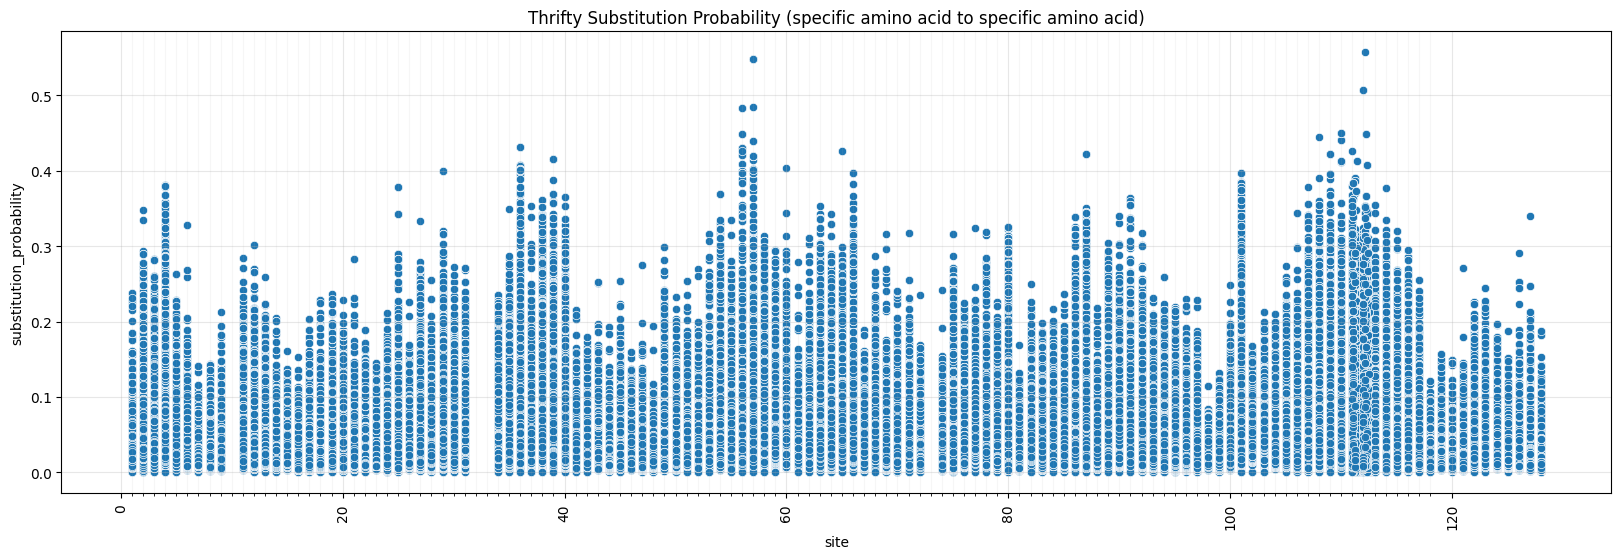

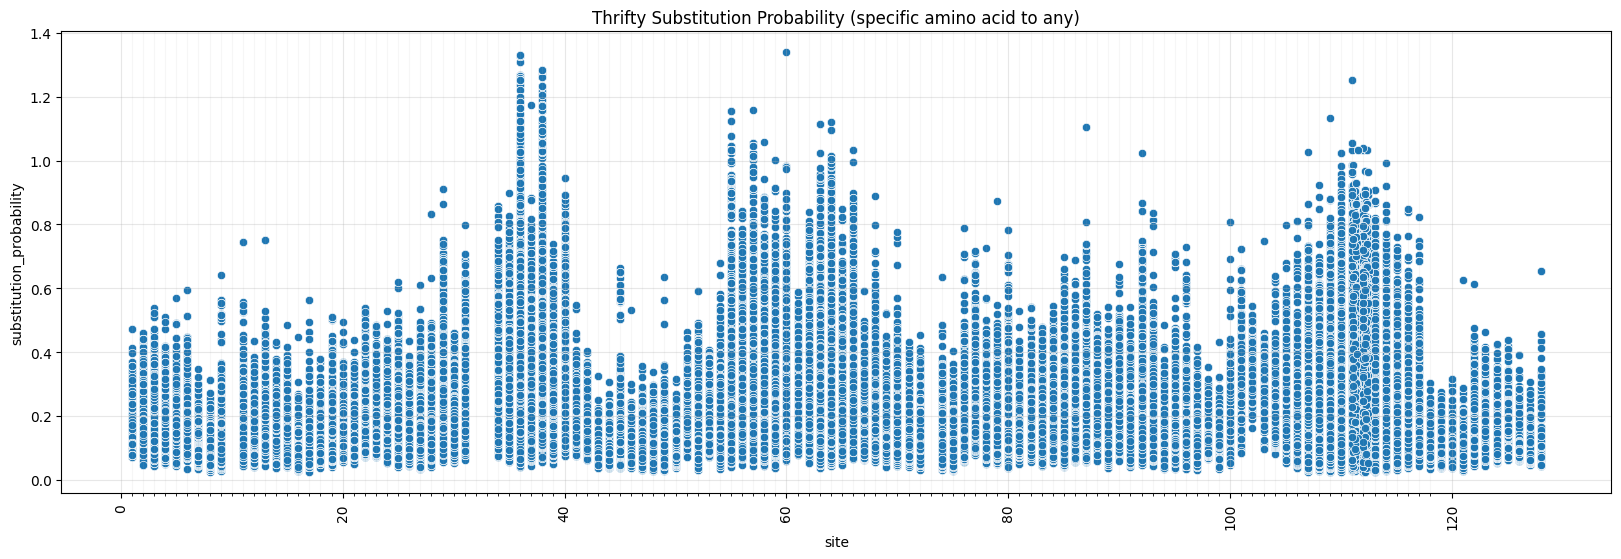

In [3]:
## View subsitution probabilites for specific amino acid to specific amino acid and from specific amino acid to any

fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to specific amino acid)')




fig, ax = plt.subplots(figsize=(20, 6))
sns.scatterplot(MutabilityContainer.aa_to_any_neutral_df, x='site', y='substitution_probability', ax=ax)

# Rotate labels
ax.tick_params(axis='x', rotation=90)
ax.grid(True, alpha=0.3)

# Add minor grid lines for every site
ax.set_xticks(range(0, 119), minor=True)
ax.grid(True, which='minor', alpha=0.1)
ax.set_title('Thrifty Substitution Probability (specific amino acid to any)')


/tmp/ipykernel_1344462/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)
/tmp/ipykernel_1344462/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['site'] = plot_data['site'].astype(float)
/tmp/ipykernel_1344462/2012362620.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

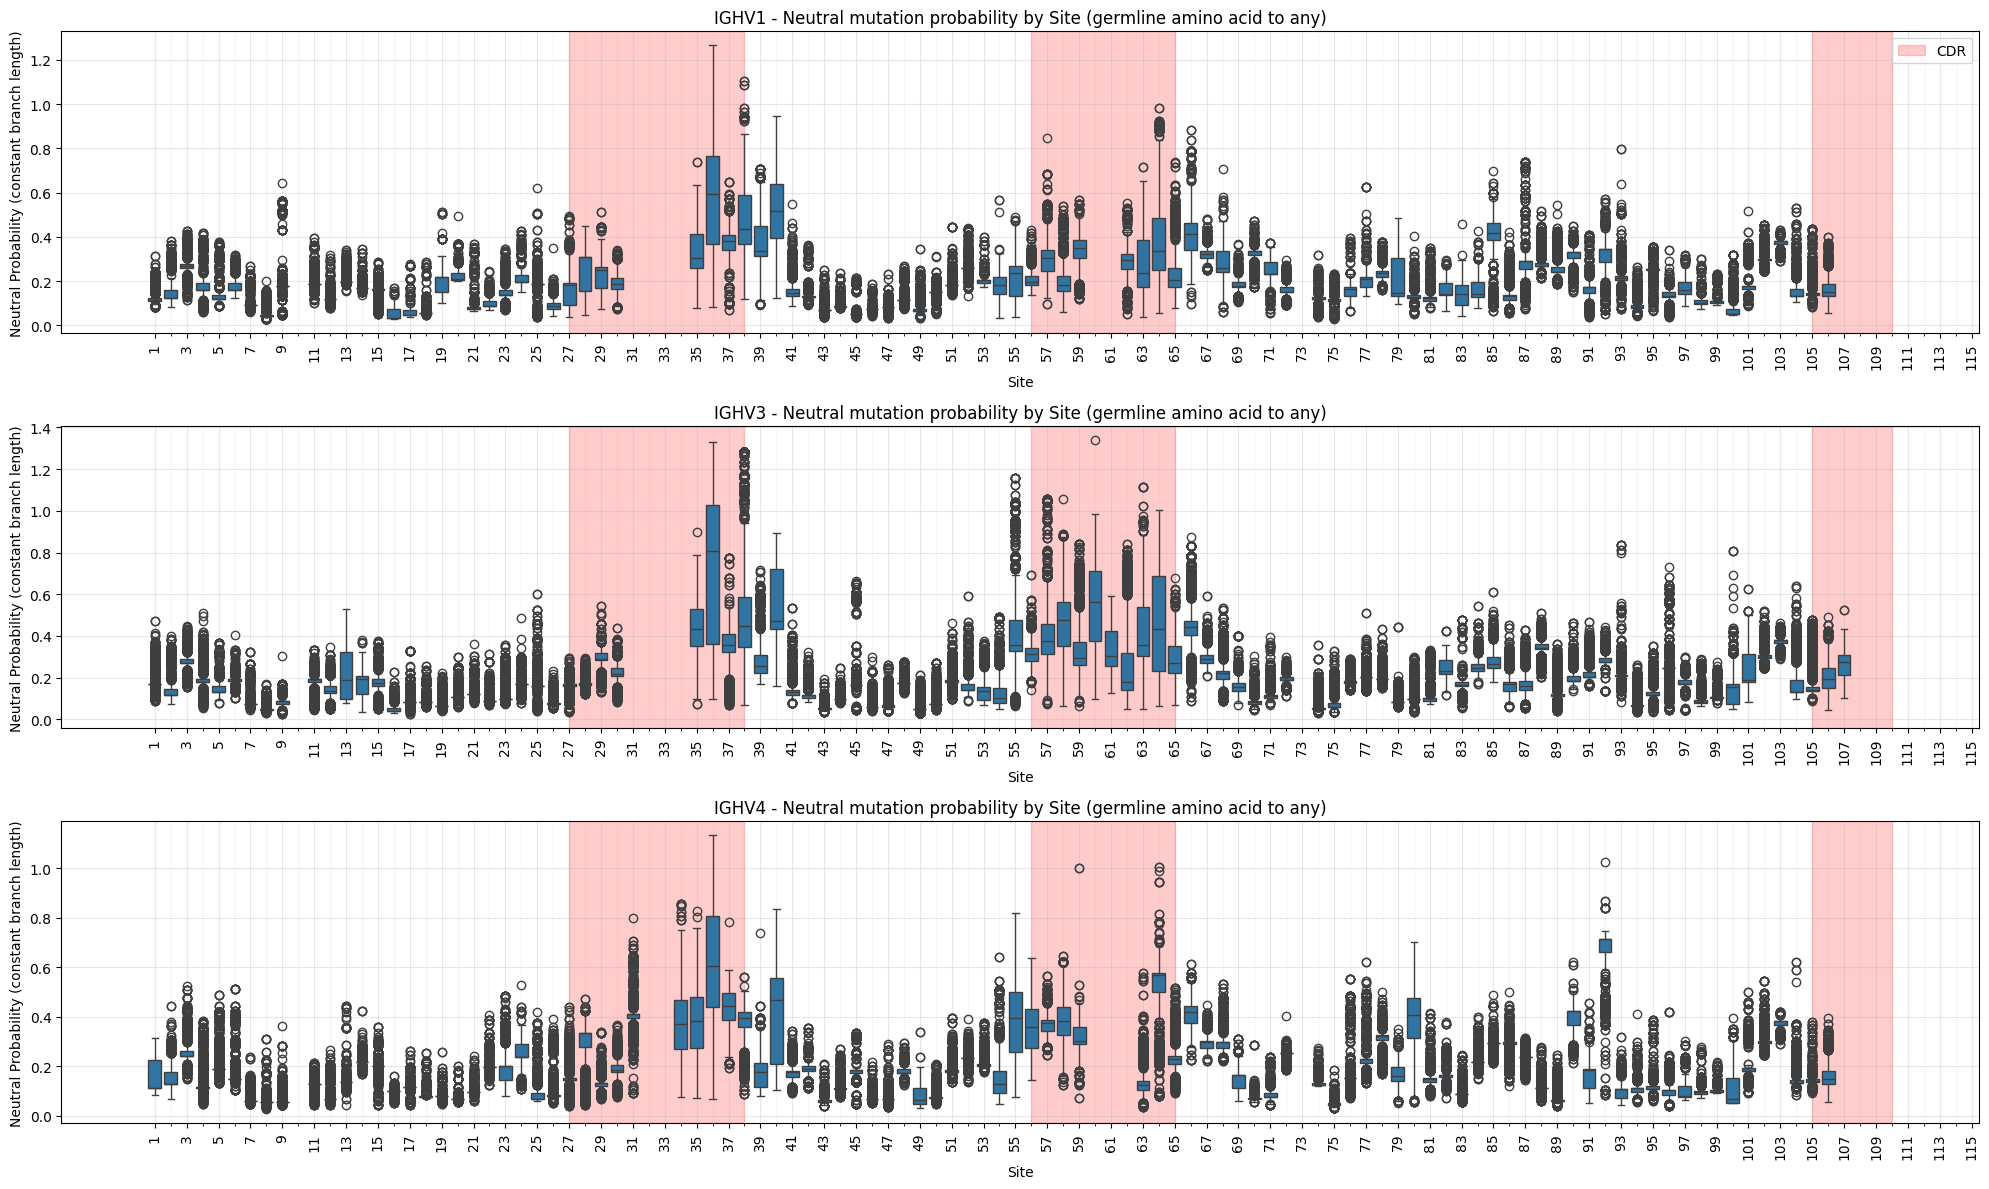

In [4]:
# View distributions of subsitution probabilites for specific amino acid to any amino acid by site, per V family



fig, axes = plt.subplots(3, 1, figsize=(20, 12))

v_families = ['IGHV1', 'IGHV3', 'IGHV4']

# Define CDR regions
cdr_regions = [
    (27, 38),   # CDR1
    (56, 65),   # CDR2
    (105, 110)  # CDR3 (shortened for V genes only)
]

for i, v_family in enumerate(v_families):
    # Filter data for current V family
    plot_data = MutabilityContainer.aa_to_any_neutral_df[
        (MutabilityContainer.aa_to_any_neutral_df.v_family == v_family) & 
        (MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True)
    ]
    plot_data['site'] = plot_data['site'].astype(float)
    
    # Get all unique pcp_index values to create dummy rows for missing sites
    unique_pcps = plot_data['pcp_index'].unique()
    
    # Create a complete grid of all pcp_index x site combinations
    complete_grid = []
    for pcp in unique_pcps:
        for site in range(1, 120):
            complete_grid.append({'pcp_index': pcp, 'site': site})
    
    complete_df = pd.DataFrame(complete_grid)
    
    # Merge with actual data, filling missing values with NaN
    plot_data_complete = pd.merge(complete_df, plot_data, on=['pcp_index', 'site'], how='left')
    
    # Create the boxplot with complete data (NaN values will be ignored automatically)
    sns.boxplot(data=plot_data_complete, x='site', y='substitution_probability', ax=axes[i])
    
    # Set x-axis ticks to show every 2nd site
    axes[i].set_xticks(range(0, 119, 2))
    axes[i].set_xticklabels(range(1, 120, 2))
    
    # Rotate labels
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, alpha=0.3)
    
    # Add minor grid lines for every site
    axes[i].set_xticks(range(0, 119), minor=True)
    axes[i].grid(True, which='minor', alpha=0.1)
    
    # Add labels
    axes[i].set_xlabel('Site')
    axes[i].set_ylabel('Neutral Probability (constant branch length)')
    axes[i].set_title(f'{v_family} - Neutral mutation probability by Site (germline amino acid to any)')
    
    # Add CDR background regions - now the indexing matches site numbers directly
    for cdr_start, cdr_end in cdr_regions:
        # Convert from 1-based site numbering to 0-based boxplot indexing
        start_idx = cdr_start - 1
        end_idx = cdr_end - 1 
        axes[i].axvspan(start_idx, end_idx, alpha=0.2, color='red', 
                       label='CDR' if cdr_start == cdr_regions[0][0] else "")
    
    # Add legend only to the first plot to avoid repetition
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

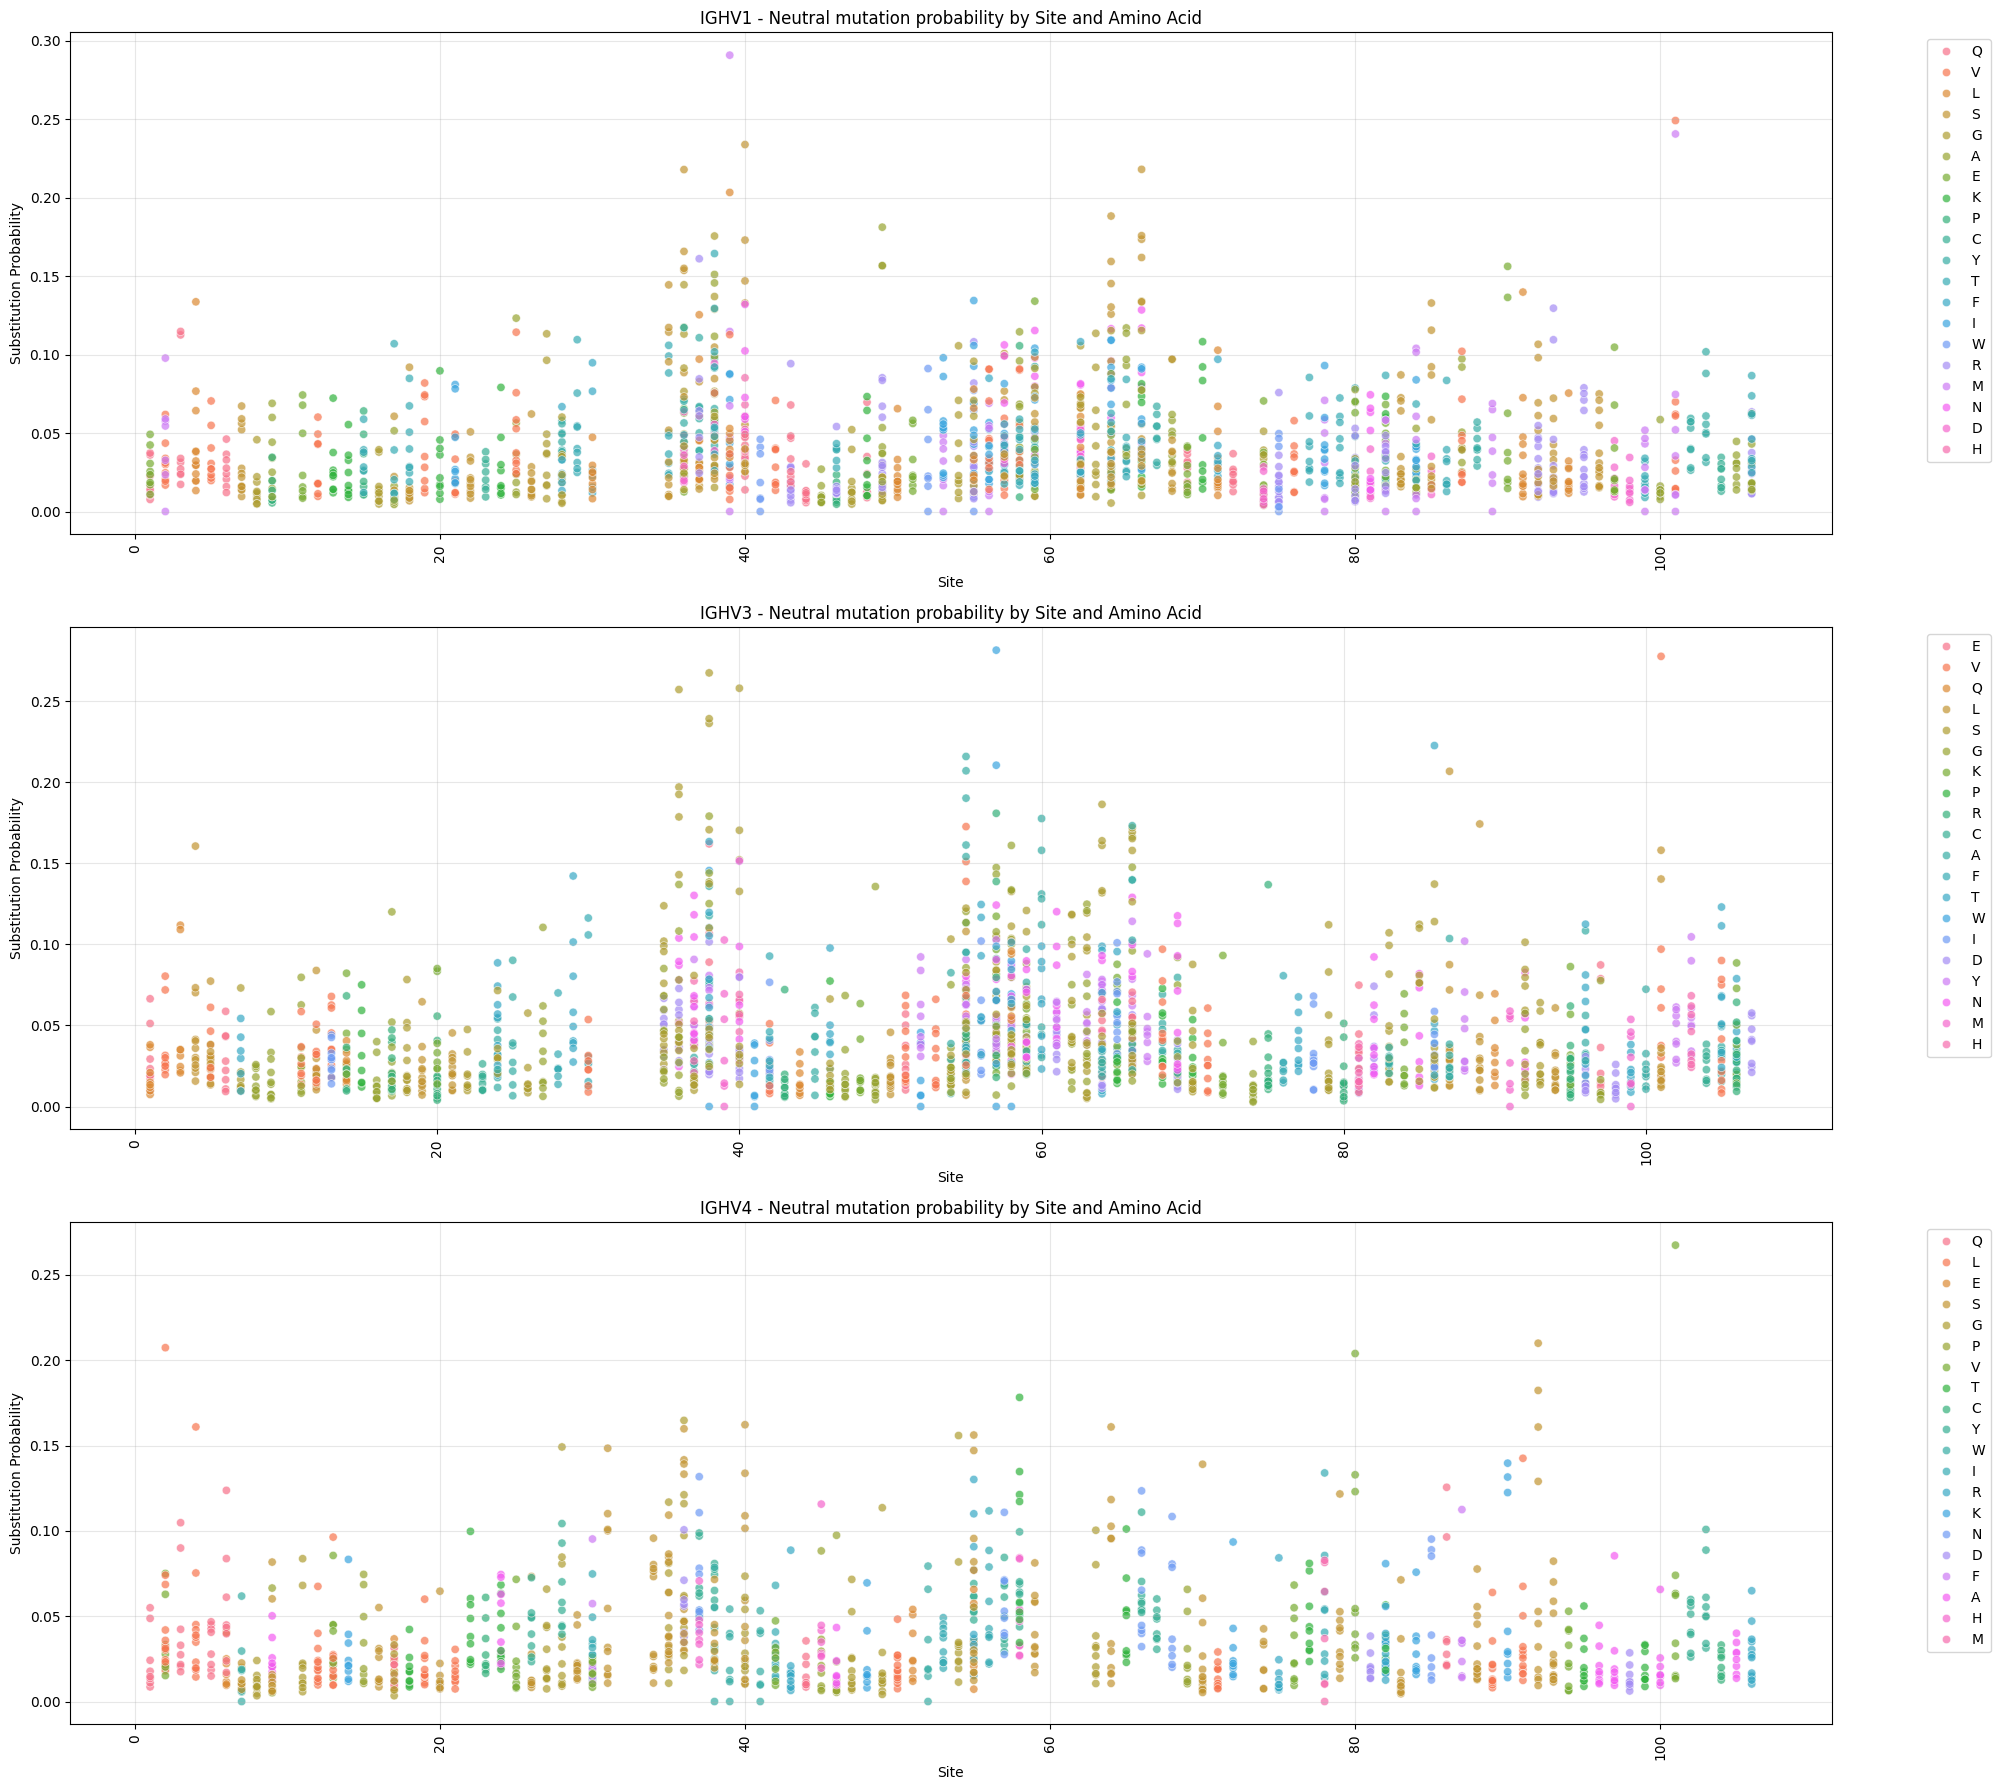

In [5]:
# Create 3 scatter plots in a column for IGHV1, IGHV3, IGHV4
fig, axes = plt.subplots(3, 1, figsize=(20, 18))

v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, v_family in enumerate(v_families):
    # Filter data for current V family and aggregate
    plot_data = MutabilityContainer.aa_neutral_df[
        (MutabilityContainer.aa_neutral_df.v_family == v_family) &
        (MutabilityContainer.aa_neutral_df.is_germline_aa == True)
    ].groupby(['site', 'current_aa', 'transition_aa'], sort=False).agg({'substitution_probability':'mean'}).reset_index()
    
    # Create scatter plot
    sns.scatterplot(data=plot_data,
                    x='site', y='substitution_probability', hue='current_aa', alpha=0.7, ax=axes[i])
    
    # Rotate labels
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].grid(True, alpha=0.3)
    
    # Set title for each plot
    axes[i].set_title(f'{v_family} - Neutral mutation probability by Site and Amino Acid')
    axes[i].set_xlabel('Site')
    axes[i].set_ylabel('Substitution Probability')
    
    # Move legend to outside
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [19]:
### sanity check to surprising sites
MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.site == 38) &
                                  (MutabilityContainer.aa_neutral_df.v_gene == 'IGHV3-23*01') & 
                                  #(MutabilityContainer.aa_neutral_df.current_aa == 'T') &
                                  (MutabilityContainer.aa_neutral_df.is_germline_codon == True)].groupby(
    ['current_aa', 'transition_aa']).agg({'substitution_probability':'mean'}                               
                                  ).reset_index()



,current_aa,transition_aa,substitution_probability
0,(A),(A),0.106246
1,(A),(D),0.078066
2,(A),(G),0.139179
3,(A),(P),0.048172
4,(A),(S),0.044036
5,(A),(T),0.069972
6,(A),(V),0.069691


## compare thrifty rates (from specific aa to any) to DNSM

In [7]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)


## add germline information
site_sub_probs_df = add_germline_information(pcp_df, site_sub_probs_df, germline_codons_path="germline/germline_codons.csv")


site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


In [8]:
neutral_grouped_data = MutabilityContainer.aa_to_any_neutral_df[(MutabilityContainer.aa_to_any_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_to_any_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'v_family', 'is_cdr'], sort=False).agg({'substitution_probability':'mean'}).reset_index()
dnsm_grouped_data = site_sub_probs_df[(site_sub_probs_df.is_germline_aa == True) & (site_sub_probs_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'v_family'], sort=False).agg({'log_selection_factor':'mean'}).reset_index()

compare_neutral_dnsm = pd.merge(neutral_grouped_data, dnsm_grouped_data.rename(columns={'parent_aa':'current_aa'}), on=['site', 'current_aa', 'v_family'], how='inner')
compare_neutral_dnsm['log_selection_factor'] = compare_neutral_dnsm['log_selection_factor'].clip(lower=-4)


In [20]:
# Define highlight sites and their colors
#highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 42: 'purple', 57: 'blue', 64: 'cyan', 66: 'magenta'}
highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 42: 'purple', 57: 'blue', 64: 'cyan', 66: 'magenta', 56:'brown', 106:'pink'}


## Choose specific sites and amino acids per v family from the entrenchment dasm analysis
entrenchment_directory = '_output/entrenchment_analysis/'
entrenchement_dfs = []
for f in os.listdir(entrenchment_directory):
    if 'within' in f:
        entrenchment_df = pd.read_csv(os.path.join(entrenchment_directory, f))
        entrenchement_dfs.append(entrenchment_df)

entrenchement_dfs = pd.concat(entrenchement_dfs, axis=0)




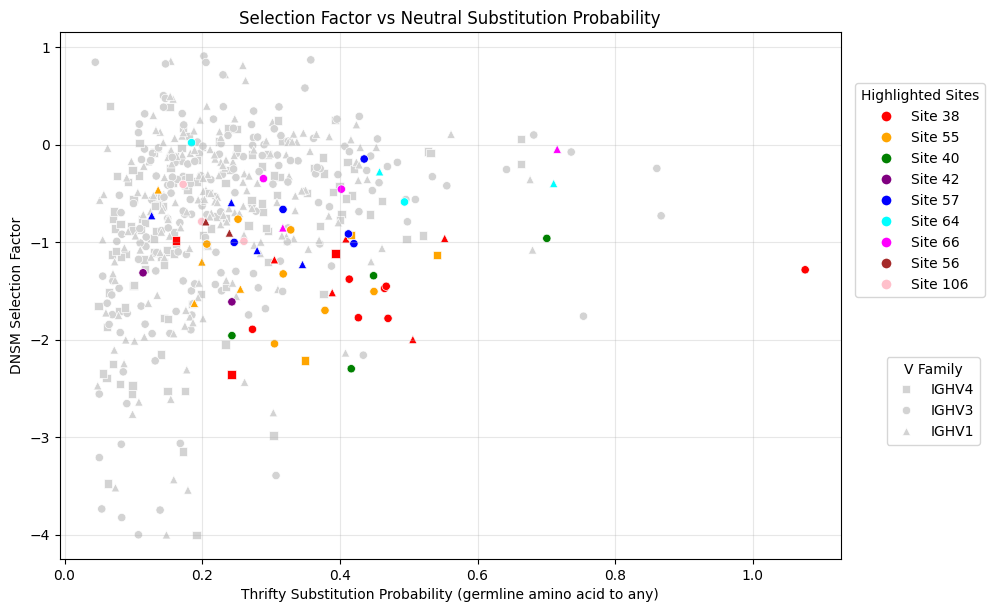

In [21]:


# Create the base scatter plot with v_family as symbols (style) instead of color
fig, ax = plt.subplots(figsize=(10, 6))

# Create custom marker mapping with triangle for IGHV1
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}  # triangle, circle, square

# Base plot with v_family as markers/symbols and neutral colors
sns.scatterplot(data=compare_neutral_dnsm, 
                x='substitution_probability', 
                y='log_selection_factor', 
                style='v_family',  # Use symbols for v_family
                markers=marker_map,  # Custom marker mapping
                color='lightgray',  # Default color for all points
                ax=ax)

# Overlay highlighted sites with specific colors
highlighted_data = pd.merge(compare_neutral_dnsm, entrenchement_dfs[['v_family', 'site', 'amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa'}), on=['v_family', 'site', 'current_aa'], how='inner')
for site in highlighted_data.site.drop_duplicates().tolist():
    color = highlight_sites.get(site, 'black')  # Default to black if site not in highlight_sites
    site_data = highlighted_data[highlighted_data['site'] == site]
    if not site_data.empty:
        sns.scatterplot(data=site_data,
                       x='substitution_probability', 
                       y='log_selection_factor',
                       style='v_family',
                       markers=marker_map,  # Use same custom markers
                       color=color,
                       ax=ax,
                       legend=False)  # Don't add to legend

ax.grid(True, alpha=0.3)

# Create custom legend for site colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                         markersize=8, label=f'Site {site}') 
                  for site, color in highlight_sites.items()]

# Add the custom legend for sites
legend1 = ax.legend(handles=legend_elements, title='Highlighted Sites', 
                   loc='center left', bbox_to_anchor=(1.01, 0.7))

# Add the legend back for v_family (symbols) 
ax.add_artist(legend1)  # Keep the site legend
ax.legend(title='V Family', loc='center left', bbox_to_anchor=(1.05, 0.3))

# Adjust layout to prevent legend cutoff
plt.tight_layout()

plt.title('Selection Factor vs Neutral Substitution Probability')
plt.xlabel('Thrifty Substitution Probability (germline amino acid to any)')
plt.ylabel('DNSM Selection Factor')
plt.show()

## compare thrifty rates (from specific aa to specific aa) to DASM


In [22]:

dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)

## add germline information
aa_site_subs_selection_df_germline = add_germline_information(pcp_df, aa_site_subs_selection_df, germline_codons_path="germline/germline_codons.csv")


aa_site_subs_selection_df_germline['log_selection_factor'] = np.log(aa_site_subs_selection_df_germline['selection_factor'])


In [23]:
neutral_grouped_data = MutabilityContainer.aa_neutral_df[(MutabilityContainer.aa_neutral_df.is_germline_aa == True) & (MutabilityContainer.aa_neutral_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'current_aa', 'transition_aa', 'v_family', 'is_cdr'], sort=False).agg({'substitution_probability':'mean'}).reset_index()
dasm_grouped_data = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))].groupby(
    ['site', 'parent_aa', 'selection_factor_target_aa', 'v_family'], sort=False).agg({'log_selection_factor':'mean'}).reset_index()

compare_neutral_dasm = pd.merge(neutral_grouped_data, dasm_grouped_data.rename(columns={'parent_aa':'current_aa', 'selection_factor_target_aa':'transition_aa'}), on=['site', 'current_aa', 'transition_aa', 'v_family'], how='inner')
compare_neutral_dasm['log_selection_factor'] = compare_neutral_dasm['log_selection_factor'].clip(lower=-4)


##### visualize comparison of neutral model and dasm selection factors, different options of same data

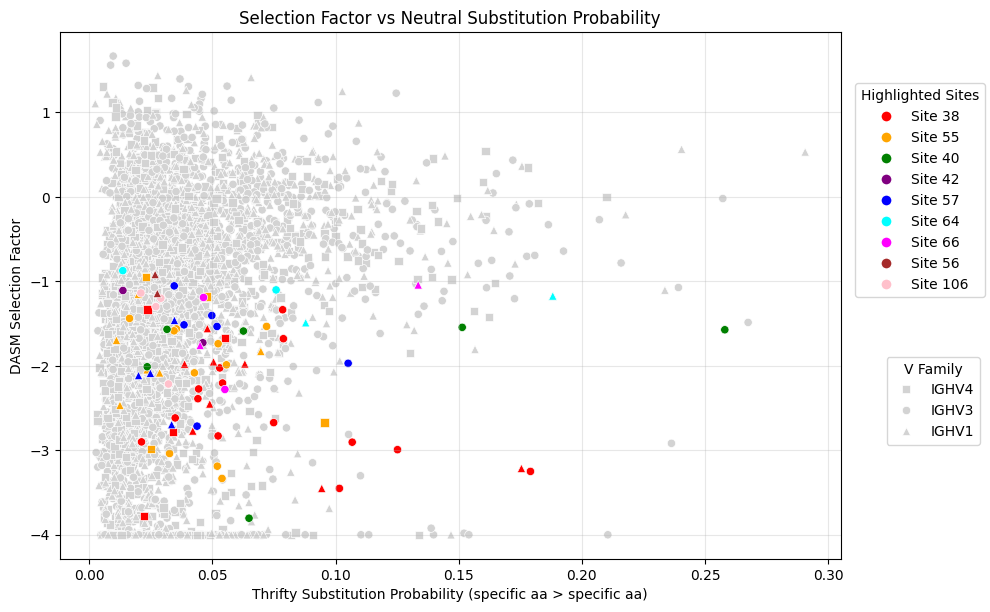

In [24]:

# Create the base scatter plot with v_family as symbols (style) instead of color
fig, ax = plt.subplots(figsize=(10, 6))

# Create custom marker mapping with triangle for IGHV1
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}  # triangle, circle, square

# Base plot with v_family as markers/symbols and neutral colors
sns.scatterplot(data=compare_neutral_dasm, 
                x='substitution_probability', 
                y='log_selection_factor', 
                style='v_family',  # Use symbols for v_family
                markers=marker_map,  # Custom marker mapping
                color='lightgray',  # Default color for all points
                ax=ax)


# Overlay highlighted sites with specific colors
highlighted_data = pd.merge(compare_neutral_dasm, entrenchement_dfs[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'
                                                                                                                                }), on=['v_family', 'site', 'current_aa', 'transition_aa'], how='inner')
for site in highlighted_data.site.drop_duplicates().tolist():
    color = highlight_sites.get(site, 'black')  # Default to black if site not in highlight_sites
    site_data = highlighted_data[highlighted_data['site'] == site]
    if not site_data.empty:
        sns.scatterplot(data=site_data,
                       x='substitution_probability', 
                       y='log_selection_factor',
                       style='v_family',
                       markers=marker_map,  # Use same custom markers
                       color=color,
                       ax=ax,
                       legend=False)  # Don't add to legend

# # Overlay highlighted sites with specific colors
# for site, color in highlight_sites.items():
#     site_data = compare_neutral_dasm[compare_neutral_dasm['site'] == site]
#     if not site_data.empty:
#         sns.scatterplot(data=site_data,
#                        x='substitution_probability', 
#                        y='log_selection_factor',
#                        style='v_family',
#                        markers=marker_map,  # Use same custom markers
#                        color=color,
#                        ax=ax,
#                        legend=False)  # Don't add to legend

ax.grid(True, alpha=0.3)

# Create custom legend for site colors
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                         markersize=8, label=f'Site {site}') 
                  for site, color in highlight_sites.items()]

# Add the custom legend for sites
legend1 = ax.legend(handles=legend_elements, title='Highlighted Sites', 
                   loc='center left', bbox_to_anchor=(1.01, 0.7))

# Add the legend back for v_family (symbols) 
ax.add_artist(legend1)  # Keep the site legend
ax.legend(title='V Family', loc='center left', bbox_to_anchor=(1.05, 0.3))

# Adjust layout to prevent legend cutoff
plt.tight_layout()

plt.title('Selection Factor vs Neutral Substitution Probability')
plt.xlabel('Thrifty Substitution Probability (specific aa > specific aa)')
plt.ylabel('DASM Selection Factor')
plt.show()

In [27]:
highlighted_data

,site,current_aa,transition_aa,v_family,is_cdr,substitution_probability,log_selection_factor
0,38.0,(Y),(S),IGHV4,True,0.055128,-1.674281
1,55.0,(Y),(S),IGHV4,False,0.047843,-1.179862
2,40.0,(S),(N),IGHV3,False,0.258045,-1.573294
3,42.0,(V),(F),IGHV3,False,0.013678,-1.108587
4,55.0,(R),(G),IGHV3,False,0.032623,-3.037829
...,...,...,...,...,...,...,...
73,42.0,(F),(V),IGHV3,False,0.046128,-1.727155
74,55.0,(S),(Y),IGHV4,False,0.022992,-0.950075
75,38.0,(S),(W),IGHV4,True,0.033998,-2.786460
76,66.0,(G),(E),IGHV3,False,0.046406,-1.191203


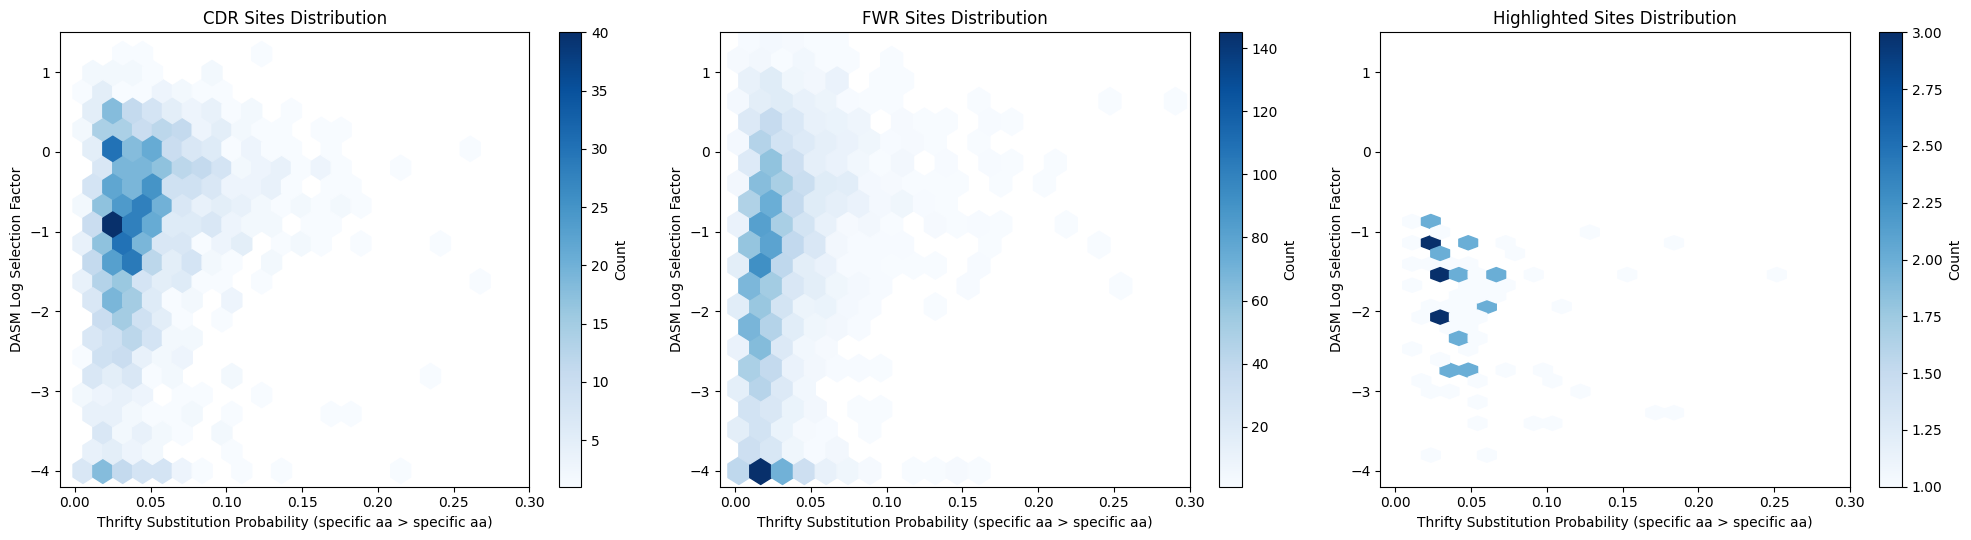

In [25]:
# Create hexbin plots for CDR, FWR, and highlighted sites
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Filter data for CDR, FWR, and highlighted sites
cdr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == True]
fwr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == False]
highlight_data = pd.merge(compare_neutral_dasm, entrenchement_dfs[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'
                                                                                                                                }), on=['v_family', 'site', 'current_aa', 'transition_aa'], how='inner')
# Pure hexbin plot 1: CDR sites
hb1 = axes[0].hexbin(cdr_data['substitution_probability'], 
                     cdr_data['log_selection_factor'],
                     gridsize=20, cmap='Blues', mincnt=1)
axes[0].set_title('CDR Sites Distribution')
axes[0].set_xlabel('Thrifty Substitution Probability (specific aa > specific aa)')
axes[0].set_ylabel('DASM Log Selection Factor')
plt.colorbar(hb1, ax=axes[0], label='Count')

# Pure hexbin plot 2: FWR sites
hb2 = axes[1].hexbin(fwr_data['substitution_probability'], 
                     fwr_data['log_selection_factor'],
                     gridsize=20, cmap='Blues', mincnt=1)
axes[1].set_title('FWR Sites Distribution')
axes[1].set_xlabel('Thrifty Substitution Probability (specific aa > specific aa)')
axes[1].set_ylabel('DASM Log Selection Factor')
plt.colorbar(hb2, ax=axes[1], label='Count')

# Pure hexbin plot 3: Highlighted sites
hb3 = axes[2].hexbin(highlight_data['substitution_probability'], 
                     highlight_data['log_selection_factor'],
                     gridsize=20, cmap='Blues', mincnt=1)
axes[2].set_title('Highlighted Sites Distribution')
axes[2].set_xlabel('Thrifty Substitution Probability (specific aa > specific aa)')
axes[2].set_ylabel('DASM Log Selection Factor')
plt.colorbar(hb3, ax=axes[2], label='Count')

for ax in axes:
    ax.set_xlim(-0.01, 0.3)
    ax.set_ylim(-4.2, 1.5)
plt.tight_layout()
plt.show()

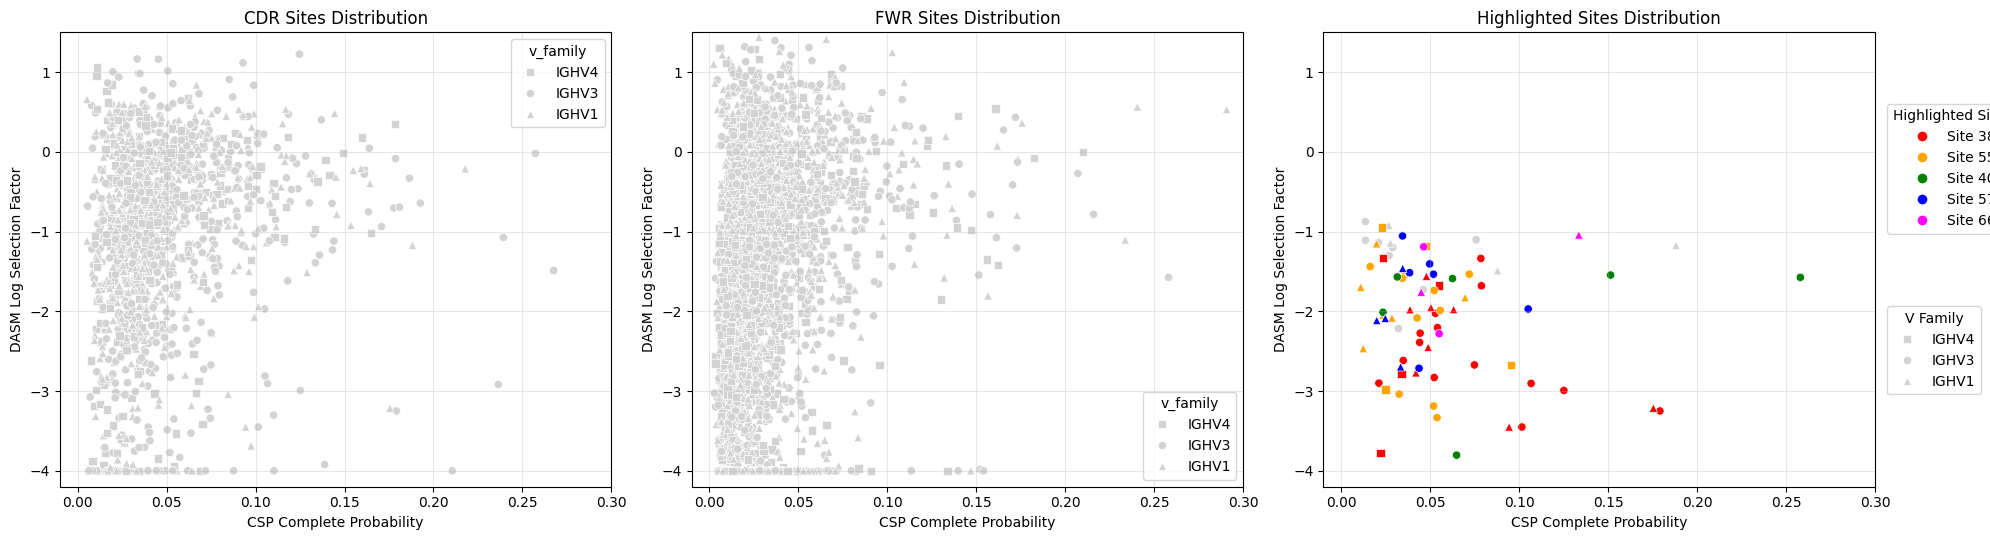

In [26]:
# Define highlight sites and their colors
highlight_sites = {38: 'red', 55: 'orange', 40: 'green', 57: 'blue', 66: 'magenta'}

# Create three scatter plots for CDR, FWR, and highlighted sites
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Create custom marker mapping with triangle for IGHV1
marker_map = {'IGHV1': '^', 'IGHV3': 'o', 'IGHV4': 's'}  # triangle, circle, square

# Filter data for CDR, FWR, and highlighted sites
cdr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == True]
fwr_data = compare_neutral_dasm[compare_neutral_dasm['is_cdr'] == False]
highlight_data = pd.merge(compare_neutral_dasm, entrenchement_dfs[['v_family', 'site', 'amino_acid', 'target_amino_acid']].drop_duplicates().rename(columns={'amino_acid':'current_aa', 'target_amino_acid':'transition_aa'
                                                                                                                                }), on=['v_family', 'site', 'current_aa', 'transition_aa'], how='inner')
datasets = [
    (cdr_data, 'CDR Sites Distribution', axes[0]),
    (fwr_data, 'FWR Sites Distribution', axes[1]),
    (highlight_data, 'Highlighted Sites Distribution', axes[2])
]

for data, title, ax in datasets:
    # Base plot with v_family as markers/symbols and neutral colors
    sns.scatterplot(data=data, 
                    x='substitution_probability', 
                    y='log_selection_factor', 
                    style='v_family',  # Use symbols for v_family
                    markers=marker_map,  # Custom marker mapping
                    color='lightgray',  # Default color for all points
                    ax=ax)
    
    # For highlighted sites plot, overlay with colors
    if title == 'Highlighted Sites Distribution':
        for site, color in highlight_sites.items():
            site_data = data[data['site'] == site]
            if not site_data.empty:
                sns.scatterplot(data=site_data,
                               x='substitution_probability', 
                               y='log_selection_factor',
                               style='v_family',
                               markers=marker_map,
                               color=color,
                               ax=ax,
                               legend=False)
    
    ax.set_title(title)
    ax.set_xlabel('CSP Complete Probability')
    ax.set_ylabel('DASM Log Selection Factor')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.01, 0.3)
    ax.set_ylim(-4.2, 1.5)

# Add legends only to the highlighted sites plot
if len(highlight_data) > 0:
    # Create custom legend for site colors
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, 
                             markersize=8, label=f'Site {site}') 
                      for site, color in highlight_sites.items()]
    
    # Add the custom legend for sites
    legend1 = axes[2].legend(handles=legend_elements, title='Highlighted Sites', 
                           loc='center left', bbox_to_anchor=(1.01, 0.7))
    
    # Add the legend back for v_family (symbols) 
    axes[2].add_artist(legend1)
    axes[2].legend(title='V Family', loc='center left', bbox_to_anchor=(1.01, 0.3))

plt.tight_layout()
plt.show()

In [ ]:
compare_neutral_dasm

,site,current_aa,transition_aa,v_family,is_cdr,substitution_probability,log_selection_factor
0,1.0,Q,K,IGHV4,False,0.008590,-3.440953
1,1.0,Q,E,IGHV4,False,0.011001,-1.673223
2,1.0,Q,P,IGHV4,False,0.013501,-4.000000
3,1.0,Q,R,IGHV4,False,0.024180,-1.565266
4,1.0,Q,L,IGHV4,False,0.014612,-1.059998
...,...,...,...,...,...,...,...
4119,65.0,P,A,IGHV3,True,0.015825,-0.395278
4120,65.0,P,S,IGHV3,True,0.029903,0.482257
4121,65.0,P,H,IGHV3,True,0.016358,-1.038788
4122,65.0,P,R,IGHV3,True,0.021267,-1.098901
